In [1]:
import os
os.chdir('..')  # Move from notebooks/ up to project root
print(os.getcwd())  # Should print: ...bangla-emotion-classifier

c:\Users\User\bangla-emotion-classifier


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_bangla_emotion_data, filter_four_emotions

print("All imports successful")

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


All imports successful


In [3]:
train_df, val_df, test_df = load_bangla_emotion_data()

train_df = filter_four_emotions(train_df)
val_df   = filter_four_emotions(val_df)
test_df  = filter_four_emotions(test_df)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")

Train size : 16000
Test size  : 2000
Val size   : 2000
Train : 14124
Val   : 1741
Test  : 1775


In [4]:
train_df.head(10)

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am feeling grouchy,3,anger
4,ive been feeling a little burdened lately wasn...,0,sadness
5,i feel as confused about life as a teenager or...,4,fear
6,i have been with petronas for years i feel tha...,1,joy
7,i feel like i have to make the suffering i m s...,0,sadness
8,i do feel that running is a divine experience ...,1,joy
9,i think it s the easiest time of year to feel ...,3,anger


In [5]:
print("--- Class Distribution (Train) ---")
print(train_df['emotion'].value_counts())
print()
print(f"Imbalance ratio: {train_df['emotion'].value_counts().max() / train_df['emotion'].value_counts().min():.2f}x")

--- Class Distribution (Train) ---
emotion
joy        5362
sadness    4666
anger      2159
fear       1937
Name: count, dtype: int64

Imbalance ratio: 2.77x


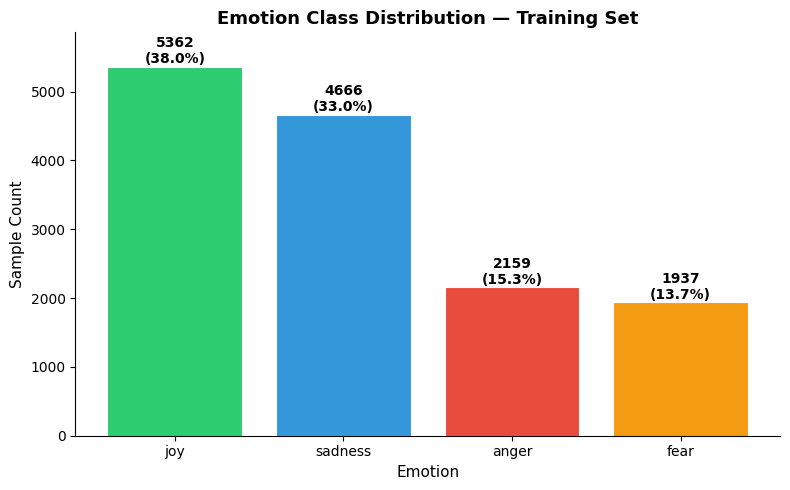

Saved to data/raw/class_distribution.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

emotion_counts = train_df['emotion'].value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

bars = ax.bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='white', linewidth=0.8)

# Annotate count + percentage on each bar
total = len(train_df)
for bar, count in zip(bars, emotion_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f'{count}\n({pct:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title('Emotion Class Distribution — Training Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion', fontsize=11)
ax.set_ylabel('Sample Count', fontsize=11)
ax.set_ylim(0, emotion_counts.max() + 500)
sns.despine()

plt.tight_layout()
plt.savefig('data/raw/class_distribution.png', dpi=150)
plt.show()
print("Saved to data/raw/class_distribution.png")

In [7]:
train_df['char_count'] = train_df['text'].apply(len)
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

print("--- Text Length Statistics ---")
print(train_df[['char_count', 'word_count']].describe().round(2))

--- Text Length Statistics ---
       char_count  word_count
count    14124.00    14124.00
mean        95.99       18.99
std         55.87       10.99
min          7.00        2.00
25%         52.00       10.75
50%         85.00       17.00
75%        128.00       25.00
max        300.00       66.00


C:\Users\User\AppData\Local\Temp\ipykernel_43200\1066536867.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=emotion_order,


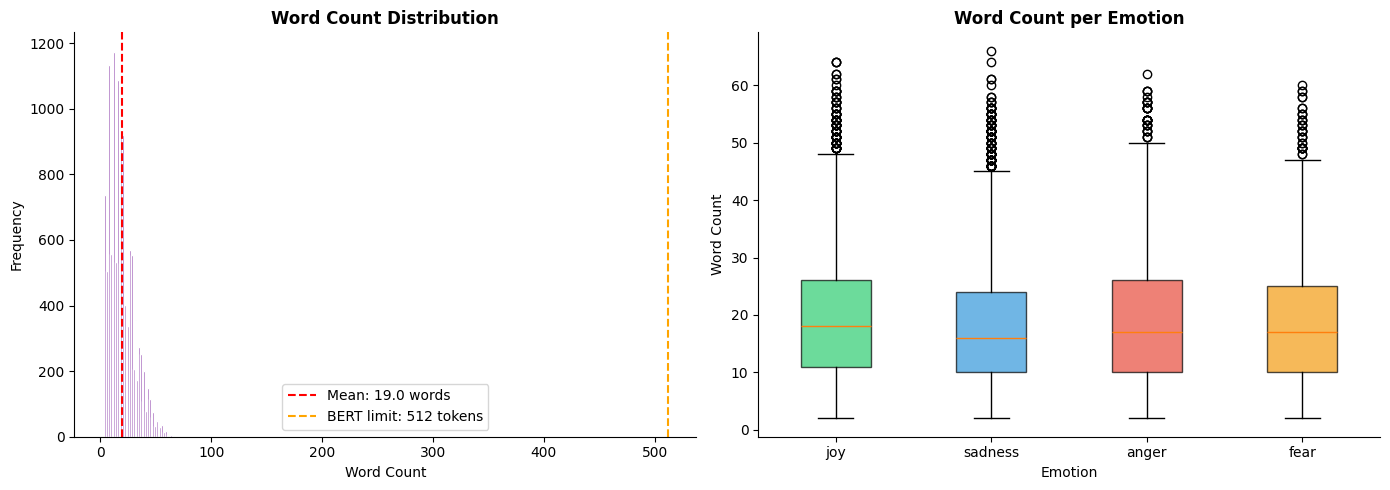

Saved to data/raw/text_length_analysis.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Plot 1: Word count histogram --
axes[0].hist(train_df['word_count'], bins=40, color='#9b59b6', edgecolor='white')
axes[0].axvline(train_df['word_count'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {train_df['word_count'].mean():.1f} words")
axes[0].axvline(512, color='orange',
                linestyle='--', linewidth=1.5,
                label="BERT limit: 512 tokens")
axes[0].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# -- Plot 2: Word count per emotion --
emotion_order = ['joy', 'sadness', 'anger', 'fear']
colors        = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
data_to_plot  = [train_df[train_df['emotion'] == e]['word_count'].values
                 for e in emotion_order]

bp = axes[1].boxplot(data_to_plot, labels=emotion_order,
                     patch_artist=True, notch=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Word Count per Emotion', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Word Count')

sns.despine()
plt.tight_layout()
plt.savefig('data/raw/text_length_analysis.png', dpi=150)
plt.show()
print("Saved to data/raw/text_length_analysis.png")

In [9]:
print("=" * 60)
print("SAMPLE TEXTS PER EMOTION — Read these carefully")
print("=" * 60)

for emotion in ['joy', 'sadness', 'fear', 'anger']:
    print(f"\n{'─' * 40}")
    print(f"  {emotion.upper()}")
    print(f"{'─' * 40}")
    samples = train_df[train_df['emotion'] == emotion]['text'].head(5)
    for i, text in enumerate(samples, 1):
        print(f"  {i}. {text}")

SAMPLE TEXTS PER EMOTION — Read these carefully

────────────────────────────────────────
  JOY
────────────────────────────────────────
  1. i have been with petronas for years i feel that petronas has performed well and made a huge profit
  2. i do feel that running is a divine experience and that i can expect to have some type of spiritual encounter
  3. i have immense sympathy with the general point but as a possible proto writer trying to find time to write in the corners of life and with no sign of an agent let alone a publishing contract this feels a little precious
  4. i do not feel reassured anxiety is on each side
  5. i have the feeling she was amused and delighted

────────────────────────────────────────
  SADNESS
────────────────────────────────────────
  1. i didnt feel humiliated
  2. i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
  3. ive been feeling a little burdened lately wasnt sure why that was
  4. i 

In [10]:
print("""
╔══════════════════════════════════════════════════════════╗
║           PHASE 1 SUMMARY — DATASET AUDIT                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Dataset   : dair-ai/emotion (English)                   ║
║  Emotions  : joy, sadness, anger, fear                   ║
║                                                          ║
║  Split sizes                                             ║
║    Train   : 14,124                                      ║
║    Val     :  1,741                                      ║
║    Test    :  1,775                                      ║
║                                                          ║
║  Class imbalance                                         ║
║    joy     : 38%  ██████████                             ║
║    sadness : 33%  ████████                               ║
║    anger   : 15%  ████                                   ║
║    fear    : 14%  ███                                    ║
║    Ratio   : 2.77x  ← needs handling                    ║
║                                                          ║
║  Text length                                             ║
║    Mean    : 19 words                                    ║
║    Max     : 66 words  ← well within BERT 512 limit     ║
║                                                          ║
║  Problems found                                          ║
║    ✗ Label noise — mixed emotions mislabeled             ║
║    ✗ Dataset bias — all texts contain "feel/feeling"     ║
║    ✗ Class imbalance — joy 2.77x more than fear          ║
║                                                          ║
║  Phase 2 actions needed                                  ║
║    → Text cleaning and normalization                     ║
║    → Handle class imbalance (weighted loss)              ║
║    → Stratified train/val/test split verification        ║
║    → Unicode normalization (critical for Bangla)         ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║           PHASE 1 SUMMARY — DATASET AUDIT                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Dataset   : dair-ai/emotion (English)                   ║
║  Emotions  : joy, sadness, anger, fear                   ║
║                                                          ║
║  Split sizes                                             ║
║    Train   : 14,124                                      ║
║    Val     :  1,741                                      ║
║    Test    :  1,775                                      ║
║                                                          ║
║  Class imbalance                                         ║
║    joy     : 38%  ██████████                             ║
║    sadness : 33%  ████████                               ║
║    anger   : 15%  ████                                   ║
║    fear    : 14%  ███